In [ ]:
# pip install deprecated


In [ ]:

# pip install mftool


In [ ]:
from mftool import Mftool
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
help(Mftool)

In [ ]:
mf=Mftool()

In [ ]:
all_scheme_codes=mf.get_scheme_codes()
all_scheme_codes

In [ ]:
details=mf.get_available_schemes('Large')
details

In [ ]:
codes=['149389','149072','149463','143247','128627']
df1=pd.DataFrame()

for i in codes:
    history_nav=mf.get_scheme_historical_nav(i,as_Dataframe=True)
    name=mf.get_scheme_details(i)['scheme_name']
    df1[name]=history_nav['nav']

df1.reset_index()

In [ ]:
columns=df1.columns.to_list

df1.reset_index(inplace=True)

df1['date']=pd.to_datetime(df1['date'],dayfirst=False)

In [ ]:
nav_cols = [c for c in df1.columns if c != 'date']

for col in nav_cols:
    
    df1[col] = pd.to_numeric(df1[col].astype(str).str.replace(',', ''), errors='coerce')



# df1.drop(columns=['level_0','index'],inplace=True)

df1


In [ ]:
df1 = df1.dropna(subset=nav_cols)



In [ ]:
df_norm = df1.copy()
df_norm[nav_cols] = (df1[nav_cols] / df1[nav_cols].iloc[0]) * 100

df_norm

In [ ]:
df_plot = df_norm.melt(id_vars='date', var_name='Mutual_Fund', value_name='Growth_Index',ignore_index=True)

#here we have data that is having nav in sep col for each mf we need to pivot it so that the 
#data is organized in such date remains as same in a col but each mf name is pivoted in such a manner that they appear multiple times based on
#which date we are viewing
#done so that the seaborn can plot them in a single line graph


In [ ]:
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
sns.lineplot(data=df_plot, x='date', y='Growth_Index', hue='Mutual_Fund')

plt.axhline(100, color='black', linestyle='--', alpha=0.5)
plt.title('MF NAV Comparison (Rebased to 100)')
plt.ylabel('Growth Index')
plt.show()

In [72]:
# from the above we can see that at macro level all the mutual funds schemes are running 

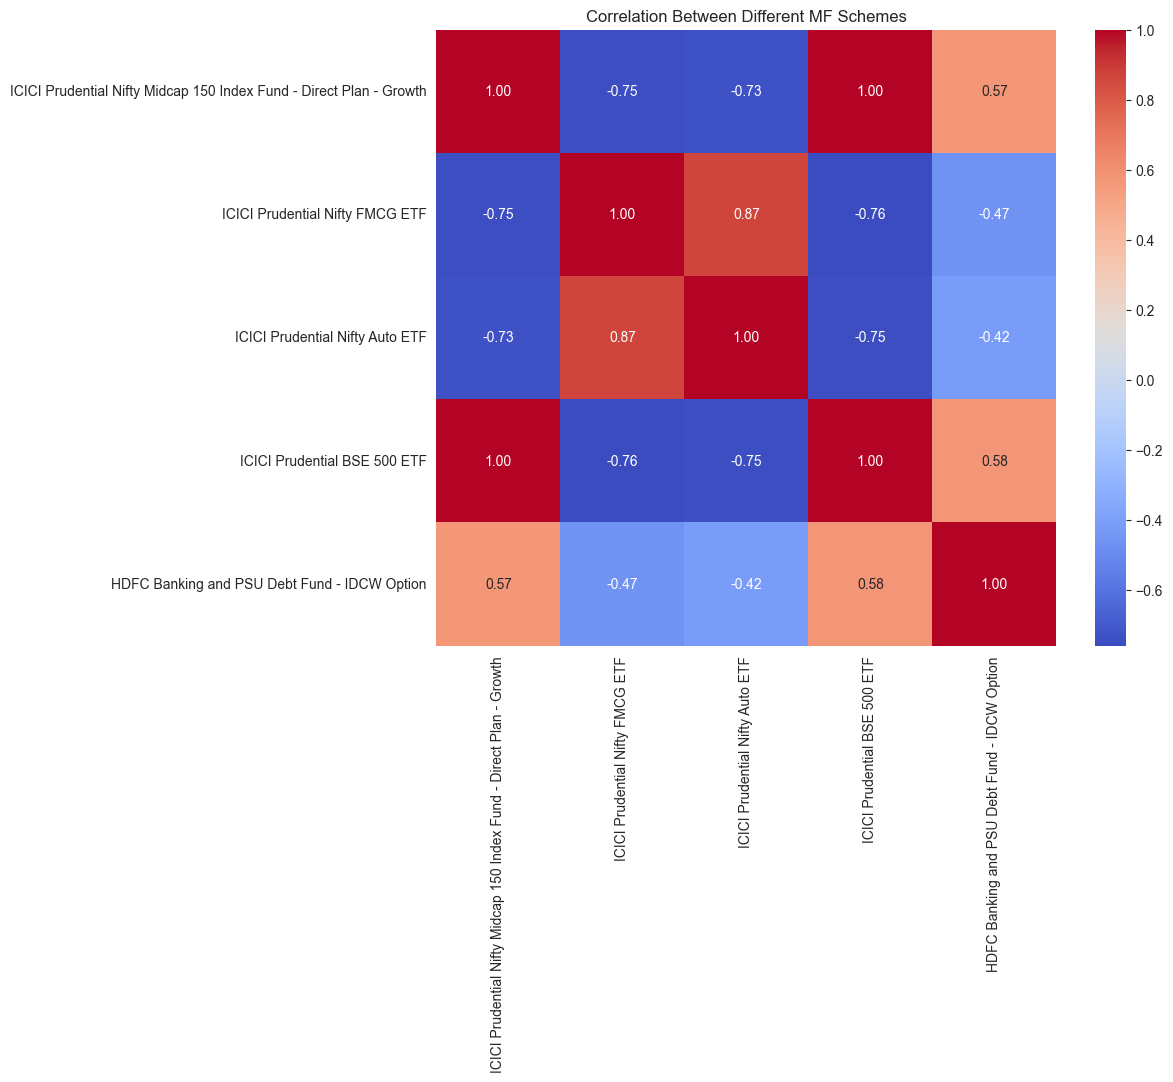

In [73]:
plt.figure(figsize=(10, 8))
correlation_matrix = df1[nav_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Different MF Schemes')
plt.show()

In [74]:
# we can observe that

<Axes: xlabel='date', ylabel='ICICI Prudential BSE 500 ETF'>

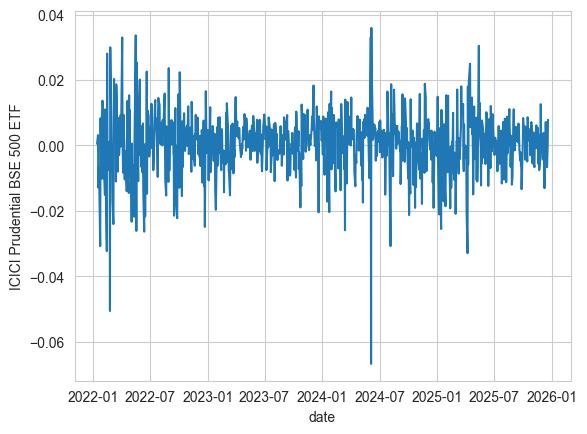

In [82]:
daily_returns=df1[nav_cols].pct_change()
df_nav_change=pd.DataFrame()
daily_returns.std()*np.sqrt(252)*100
sns.lineplot(data=daily_returns,y='ICICI Prudential BSE 500 ETF',x=df1.date)